# Model Selection: AIC, BIC, and Cross-Validation

## Learning Objectives

By the end of this notebook you will be able to:

1. Explain the **model selection problem** and why training-set fit alone is misleading.
2. Compute **Adjusted $R^2$** and explain when plain $R^2$ fails.
3. Derive and interpret **AIC** and **BIC**, including their information-theoretic motivation.
4. Implement **$k$-fold cross-validation** from scratch for linear regression.
5. Compare polynomial models using AIC, BIC, and CV error, recognising the characteristic U-shaped test-error curve.
6. Use `sklearn.model_selection.cross_val_score` and `statsmodels` AIC/BIC in practice.

## Prerequisites

- [01_simple_linear_regression.ipynb](01_simple_linear_regression.ipynb) — OLS, $R^2$, residuals
- [02_multiple_regression.ipynb](02_multiple_regression.ipynb) — design matrix, $p$ predictors
- [Module 04](../04_estimation/03_maximum_likelihood.ipynb) — maximum likelihood and log-likelihood $\ell$

In [ ]:
import sys, os, shutil
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    os.system("pip install -q statsmodels scikit-learn")

_miktex_bin = Path.home() / "AppData/Local/Programs/MiKTeX/miktex/bin/x64"
if _miktex_bin.exists() and str(_miktex_bin) not in os.environ.get("PATH", ""):
    os.environ["PATH"] += os.pathsep + str(_miktex_bin)

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

sys.path.insert(0, os.path.abspath("../../src"))
from amstats.plotting import apply_style

apply_style()


class Cfg:
    root = Path("../../").resolve()
    gif_dir = root / "media" / "gifs"
    has_latex: bool = (
        shutil.which("latex") is not None or shutil.which("pdflatex") is not None
    )

    def __init__(self):
        self.gif_dir.mkdir(parents=True, exist_ok=True)


cfg = Cfg()
rng = np.random.default_rng(42)

---

## 1. The Model Selection Problem

Given data $(x_i, y_i)$ we can always improve the **training-set fit** by adding more parameters.
A degree-$n$ polynomial passes through all $n+1$ data points exactly, yielding $R^2 = 1$ on the training set.
But such a model **memorises noise** and predicts new data terribly.

This is the **overfitting / underfitting tradeoff**:

| Regime           | Model complexity | Training error  | Test error      |
|------------------|------------------|-----------------|-----------------|
| **Underfitting** | Too low          | High            | High            |
| **Just right**   | Appropriate      | Moderate        | Low             |
| **Overfitting**  | Too high         | Very low / zero | High (blows up) |

Model selection asks: **how do we choose the right level of complexity from the data?**

We will study three families of approaches:
1. **Penalised goodness-of-fit** (Adjusted $R^2$, AIC, BIC) -- modify the training metric to account for complexity.
2. **Cross-validation** -- directly estimate out-of-sample prediction error.
3. **Regularisation** (Ridge, Lasso) -- covered in a later module.

### Generating example data

Throughout this notebook we use a simple ground truth: a cubic polynomial plus noise.

$$y = 0.5 + 1.2\,x - 0.8\,x^2 + 0.3\,x^3 + \varepsilon, \qquad \varepsilon \sim \mathcal{N}(0, 1)$$

The true model is degree 3. A good model selection procedure should identify this (or something close).

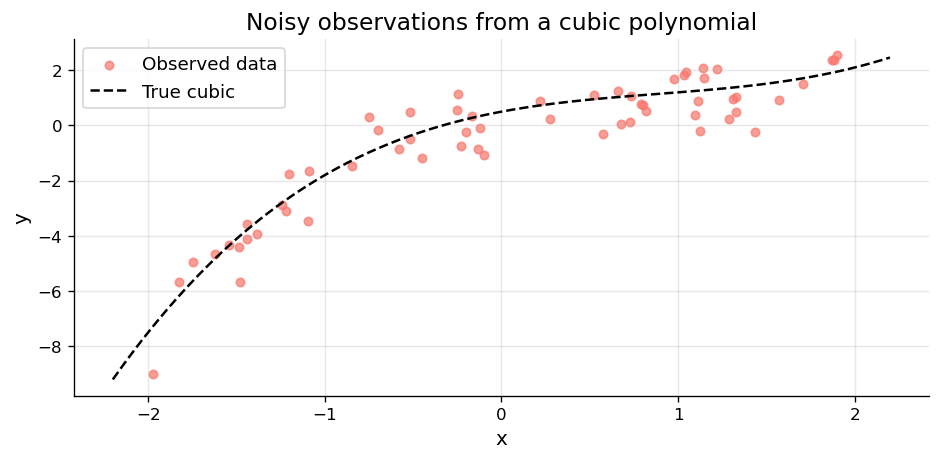

In [ ]:
# --- Ground-truth data ---
n = 60
x = rng.uniform(-2, 2, n)
x_sorted = np.sort(x)


def true_function(t):
    return 0.5 + 1.2 * t - 0.8 * t**2 + 0.3 * t**3


y = true_function(x) + rng.normal(0, 1.0, n)

# Dense grid for plotting smooth curves
x_grid = np.linspace(-2.2, 2.2, 300)

fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(x, y, s=25, alpha=0.7, label="Observed data")
ax.plot(x_grid, true_function(x_grid), "k--", linewidth=1.5, label="True cubic")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Noisy observations from a cubic polynomial")
ax.legend()
plt.tight_layout()
plt.show()

---

## 2. Adjusted $R^2$

Recall that

$$R^2 = 1 - \frac{\text{RSS}}{\text{TSS}} = 1 - \frac{\sum(y_i - \hat{y}_i)^2}{\sum(y_i - \bar{y})^2}$$

Adding **any** predictor (even random noise) can only decrease RSS, so $R^2$ never goes down.
This makes it useless for comparing models of different complexity.

**Adjusted $R^2$** corrects for the number of predictors $p$:

$$R^2_{\text{adj}} = 1 - \frac{\text{RSS}/(n - p - 1)}{\text{TSS}/(n - 1)} = 1 - \frac{n - 1}{n - p - 1}(1 - R^2)$$

The denominator $n - p - 1$ penalises additional parameters: adding a useless predictor increases $p$ without sufficiently decreasing RSS, so $R^2_{\text{adj}}$ can actually **decrease**.

**Limitation:** Adjusted $R^2$ is simple but ad hoc. It has no formal information-theoretic justification and does not directly estimate prediction error. AIC and BIC are more principled.

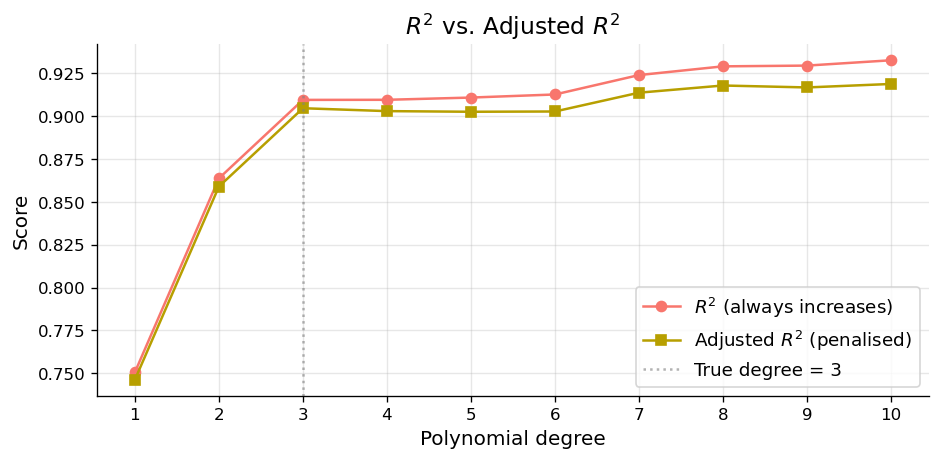

Best degree by Adjusted R²: 10


In [3]:
# Compute R² and Adjusted R² for polynomial fits of degree 1..10
max_degree = 10
degrees = np.arange(1, max_degree + 1)

r2_values = []
adj_r2_values = []

tss = np.sum((y - y.mean()) ** 2)

for d in degrees:
    coeffs = np.polyfit(x, y, d)
    y_hat = np.polyval(coeffs, x)
    rss = np.sum((y - y_hat) ** 2)
    p = d  # number of predictors (excluding intercept)
    r2 = 1 - rss / tss
    adj_r2 = 1 - (n - 1) / (n - p - 1) * (1 - r2)
    r2_values.append(r2)
    adj_r2_values.append(adj_r2)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(degrees, r2_values, "o-", label="$R^2$ (always increases)")
ax.plot(degrees, adj_r2_values, "s-", label="Adjusted $R^2$ (penalised)")
ax.axvline(3, color="grey", linestyle=":", alpha=0.6, label="True degree = 3")
ax.set_xlabel("Polynomial degree")
ax.set_ylabel("Score")
ax.set_title("$R^2$ vs. Adjusted $R^2$")
ax.set_xticks(degrees)
ax.legend()
plt.tight_layout()
plt.show()

print(f"Best degree by Adjusted R²: {degrees[np.argmax(adj_r2_values)]}")

Notice that $R^2$ increases monotonically (by construction), while Adjusted $R^2$ peaks around degree 3 and flattens or declines beyond that.

---

## 3. Information Criteria -- AIC

### Akaike's Information Criterion

**Intuition.** We want a model that is close (in some sense) to the true data-generating process.
The natural measure of "closeness" between distributions is the **Kullback-Leibler (KL) divergence**:

$$D_{\text{KL}}(f \| g) = \int f(x) \log \frac{f(x)}{g(x)} \, dx$$

Akaike (1973) showed that minimising an estimate of the expected KL divergence between the true distribution and the fitted model leads to:

$$\boxed{\text{AIC} = -2\ell(\hat{\theta}) + 2p}$$

where:
- $\ell(\hat{\theta})$ is the **maximised log-likelihood** of the model,
- $p$ is the **number of estimated parameters** (including $\sigma^2$ if estimated).

**Lower AIC is better.** The first term $-2\ell$ rewards goodness-of-fit (smaller residuals increase $\ell$). The second term $2p$ is a **complexity penalty** -- each extra parameter costs 2 units.

### AIC for Gaussian linear regression

For a linear model with Gaussian errors, the log-likelihood is:

$$\ell = -\frac{n}{2}\log(2\pi) - \frac{n}{2}\log(\hat{\sigma}^2) - \frac{n}{2}$$

where $\hat{\sigma}^2 = \text{RSS}/n$. Substituting:

$$\text{AIC} = n\log(\hat{\sigma}^2) + 2p + \text{const}$$

Since we compare models on the same data, the constant drops out. In practice we use the full formula via statsmodels.

In [ ]:
# --- Compute AIC for polynomial models degree 1..10 ---


def compute_aic_bic(x, y, degree):
    """Fit polynomial of given degree and return (AIC, BIC)."""
    n = len(y)
    coeffs = np.polyfit(x, y, degree)
    y_hat = np.polyval(coeffs, x)
    rss = np.sum((y - y_hat) ** 2)
    sigma2_hat = rss / n  # MLE of variance
    # Number of parameters: (degree+1) coefficients + 1 variance = degree + 2
    p = degree + 2
    # Log-likelihood (Gaussian)
    log_lik = -n / 2 * np.log(2 * np.pi) - n / 2 * np.log(sigma2_hat) - n / 2
    aic = -2 * log_lik + 2 * p
    bic = -2 * log_lik + p * np.log(n)
    return aic, bic


aic_values = []
bic_values = []

for d in degrees:
    aic, bic = compute_aic_bic(x, y, d)
    aic_values.append(aic)
    bic_values.append(bic)

print("Degree | AIC       | BIC")
print("-------+-----------+----------")
for d, a, b in zip(degrees, aic_values, bic_values):
    marker = " <-- min" if a == min(aic_values) else ""
    print(f"  {d:2d}   | {a:9.2f} | {b:9.2f}{marker}")

Degree | AIC       | BIC
-------+-----------+----------
   1   |    198.67 |    204.96
   2   |    164.47 |    172.85
   3   |    141.98 |    152.45
   4   |    143.95 |    156.51
   5   |    145.08 |    159.74
   6   |    145.86 |    162.61
   7   |    139.56 |    158.41
   8   |    137.42 |    158.37 <-- min
   9   |    139.05 |    162.09
  10   |    138.36 |    163.50


---

## 4. BIC (Bayesian Information Criterion)

Schwarz (1978) derived an alternative criterion from a Bayesian model-comparison perspective:

$$\boxed{\text{BIC} = -2\ell(\hat{\theta}) + p \cdot \ln(n)}$$

The only difference from AIC is the penalty: $p \cdot \ln(n)$ instead of $2p$.

Since $\ln(n) > 2$ whenever $n > e^2 \approx 7.4$, **BIC penalises complexity more heavily** for any reasonably sized dataset. This means BIC tends to select **simpler models** than AIC.

### BIC's derivation (brief)

BIC approximates the log marginal likelihood $\log p(\text{data} \mid \text{model})$ via a Laplace approximation. Choosing the model with the highest marginal likelihood is equivalent to choosing the lowest BIC. The penalty $p \cdot \ln(n)$ arises from integrating over the parameter prior.

---

## 5. AIC vs. BIC: When They Disagree

| Property         | AIC                             | BIC                                           |
|------------------|---------------------------------|-----------------------------------------------|
| Penalty          | $2p$                            | $p \cdot \ln(n)$                              |
| Heavier penalty? | Lighter for $n \geq 8$          | Heavier for $n \geq 8$                        |
| Consistency      | **Not** consistent              | **Consistent** ($P(\text{true model}) \to 1$) |
| Prediction focus | Better finite-sample prediction | Favours parsimony                             |
| Overfitting risk | Slightly higher                 | Lower                                         |

**Consistency** means that as $n \to \infty$, BIC selects the true model with probability 1 (assuming the true model is among the candidates). AIC does not have this property -- it tends to overfit slightly, even asymptotically.

However, AIC often produces better **predictive** models in finite samples, because the "true" model concept is an idealisation -- all models are approximations, and the best approximation for prediction may be slightly more complex than the "true" generating process.

**Rule of thumb:** Use BIC if you want to identify the true underlying model (scientific explanation). Use AIC if prediction accuracy is the primary goal.

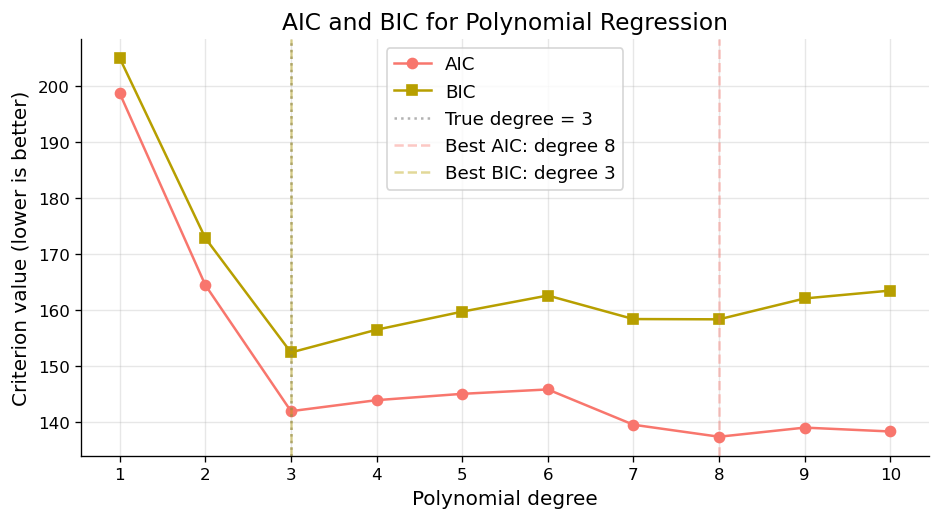

In [ ]:
# --- Plot AIC and BIC together ---

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(degrees, aic_values, "o-", label="AIC", markersize=6)
ax.plot(degrees, bic_values, "s-", label="BIC", markersize=6)
ax.axvline(3, color="grey", linestyle=":", alpha=0.6, label="True degree = 3")

best_aic_deg = degrees[np.argmin(aic_values)]
best_bic_deg = degrees[np.argmin(bic_values)]
ax.axvline(
    best_aic_deg,
    color="C0",
    linestyle="--",
    alpha=0.4,
    label=f"Best AIC: degree {best_aic_deg}",
)
ax.axvline(
    best_bic_deg,
    color="C1",
    linestyle="--",
    alpha=0.4,
    label=f"Best BIC: degree {best_bic_deg}",
)

ax.set_xlabel("Polynomial degree")
ax.set_ylabel("Criterion value (lower is better)")
ax.set_title("AIC and BIC for Polynomial Regression")
ax.set_xticks(degrees)
ax.legend()
plt.tight_layout()
plt.show()

---

## 6. Cross-Validation

Information criteria rely on distributional assumptions (Gaussian errors for AIC/BIC in the linear model). **Cross-validation (CV)** is a non-parametric, assumption-free approach: it directly estimates prediction error by holding out data.

### 6.1 The idea

1. Split data into a **training set** and a **validation (test) set**.
2. Fit the model on training data only.
3. Evaluate prediction error on the held-out validation data.
4. The model with the lowest validation error wins.

A single train/test split wastes data and has high variance. **$k$-fold CV** solves this.

### 6.2 $k$-Fold Cross-Validation

1. Randomly partition the data into $k$ equal-sized **folds** $F_1, F_2, \dots, F_k$.
2. For fold $j = 1, \dots, k$:
   - **Train** on all data except fold $F_j$.
   - **Test** on fold $F_j$: compute $\text{MSE}_j = \frac{1}{|F_j|} \sum_{i \in F_j} (y_i - \hat{y}_i)^2$.
3. The CV estimate of test error is the average:

$$\text{CV}(k) = \frac{1}{k} \sum_{j=1}^{k} \text{MSE}_j$$

Common choices: $k = 5$ or $k = 10$.

### 6.3 Leave-One-Out Cross-Validation (LOOCV)

Setting $k = n$ gives **LOOCV**: each observation serves as a single-element test set in turn. This has very low bias (training on $n - 1$ points is nearly the same as training on $n$) but high variance (the $n$ training sets overlap heavily). For linear regression, LOOCV has a closed-form shortcut:

$$\text{CV}_{\text{LOO}} = \frac{1}{n} \sum_{i=1}^{n} \left(\frac{y_i - \hat{y}_i}{1 - h_{ii}}\right)^2$$

where $h_{ii}$ is the $i$-th diagonal element of the hat matrix $\mathbf{H} = \mathbf{X}(\mathbf{X}^\top\mathbf{X})^{-1}\mathbf{X}^\top$. This requires only a single OLS fit!

### 6.4 From-scratch implementation: $k$-fold CV for polynomial regression

In [ ]:
def kfold_cv_polynomial(x, y, degree, k=10, rng=None):
    """
    From-scratch k-fold CV for polynomial regression.

    Parameters
    ----------
    x, y : array-like, shape (n,)
        Predictor and response.
    degree : int
        Polynomial degree to fit.
    k : int
        Number of folds.
    rng : numpy Generator, optional
        For reproducible shuffling.

    Returns
    -------
    cv_mse : float
        Average MSE across folds.
    fold_mses : list of float
        Per-fold MSEs.
    """
    n = len(y)
    if rng is None:
        rng = np.random.default_rng()

    # Shuffle indices and split into k folds
    indices = rng.permutation(n)
    folds = np.array_split(indices, k)

    fold_mses = []
    for j in range(k):
        # Test fold
        test_idx = folds[j]
        # Training folds = everything except fold j
        train_idx = np.concatenate([folds[i] for i in range(k) if i != j])

        x_train, y_train = x[train_idx], y[train_idx]
        x_test, y_test = x[test_idx], y[test_idx]

        # Fit polynomial on training data
        coeffs = np.polyfit(x_train, y_train, degree)
        y_pred = np.polyval(coeffs, x_test)

        # MSE on test fold
        mse_j = np.mean((y_test - y_pred) ** 2)
        fold_mses.append(mse_j)

    return np.mean(fold_mses), fold_mses


# Quick test
cv_mse, fold_mses = kfold_cv_polynomial(
    x, y, degree=3, k=10, rng=np.random.default_rng(0)
)
print(f"10-fold CV MSE for degree 3: {cv_mse:.4f}")
print(f"Per-fold MSEs: {[f'{m:.3f}' for m in fold_mses]}")

10-fold CV MSE for degree 3: 0.6148
Per-fold MSEs: ['0.461', '1.144', '0.412', '0.562', '0.904', '0.864', '0.514', '0.673', '0.443', '0.171']


In [7]:
# --- CV error for all degrees ---
cv_errors = []
cv_stds = []
train_errors = []

for d in degrees:
    cv_mse, fold_mses = kfold_cv_polynomial(x, y, d, k=10, rng=np.random.default_rng(0))
    cv_errors.append(cv_mse)
    cv_stds.append(np.std(fold_mses))

    # Training error (for comparison)
    coeffs = np.polyfit(x, y, d)
    y_hat = np.polyval(coeffs, x)
    train_errors.append(np.mean((y - y_hat) ** 2))

cv_errors = np.array(cv_errors)
cv_stds = np.array(cv_stds)
train_errors = np.array(train_errors)

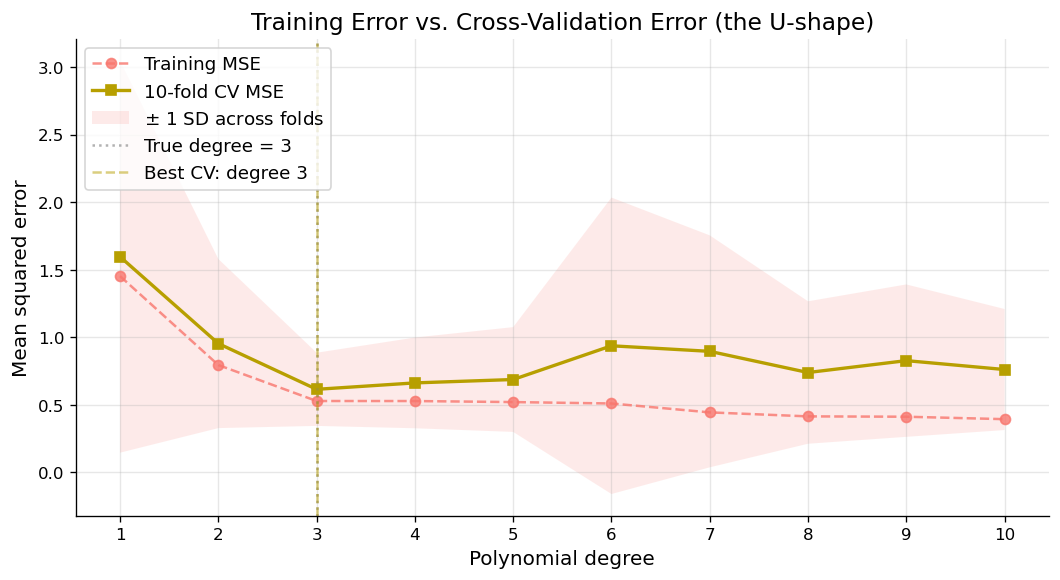

Best degree by 10-fold CV: 3


In [ ]:
# --- The U-shaped test error curve ---

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(degrees, train_errors, "o--", label="Training MSE", alpha=0.8)
ax.plot(degrees, cv_errors, "s-", label="10-fold CV MSE", linewidth=2)
ax.fill_between(
    degrees,
    cv_errors - cv_stds,
    cv_errors + cv_stds,
    alpha=0.15,
    label="$\pm$ 1 SD across folds",
)
ax.axvline(3, color="grey", linestyle=":", alpha=0.6, label="True degree = 3")

best_cv_deg = degrees[np.argmin(cv_errors)]
ax.axvline(
    best_cv_deg,
    color="C1",
    linestyle="--",
    alpha=0.5,
    label=f"Best CV: degree {best_cv_deg}",
)

ax.set_xlabel("Polynomial degree")
ax.set_ylabel("Mean squared error")
ax.set_title("Training Error vs. Cross-Validation Error (the U-shape)")
ax.set_xticks(degrees)
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

print(f"Best degree by 10-fold CV: {best_cv_deg}")

**Key observation:** Training MSE decreases monotonically as we add parameters. But the CV (test) error follows a **U-shape** -- it decreases as the model captures true structure, reaches a minimum around the true complexity, and then increases as the model starts fitting noise (overfitting).

This U-shaped curve is the most important plot in model selection. It directly demonstrates the bias-variance tradeoff at work.

---

## 7. Worked Example: Visualising Overfitting

Let us overlay polynomial fits of degree 1, 3, 5, and 10 on the data to see overfitting visually.

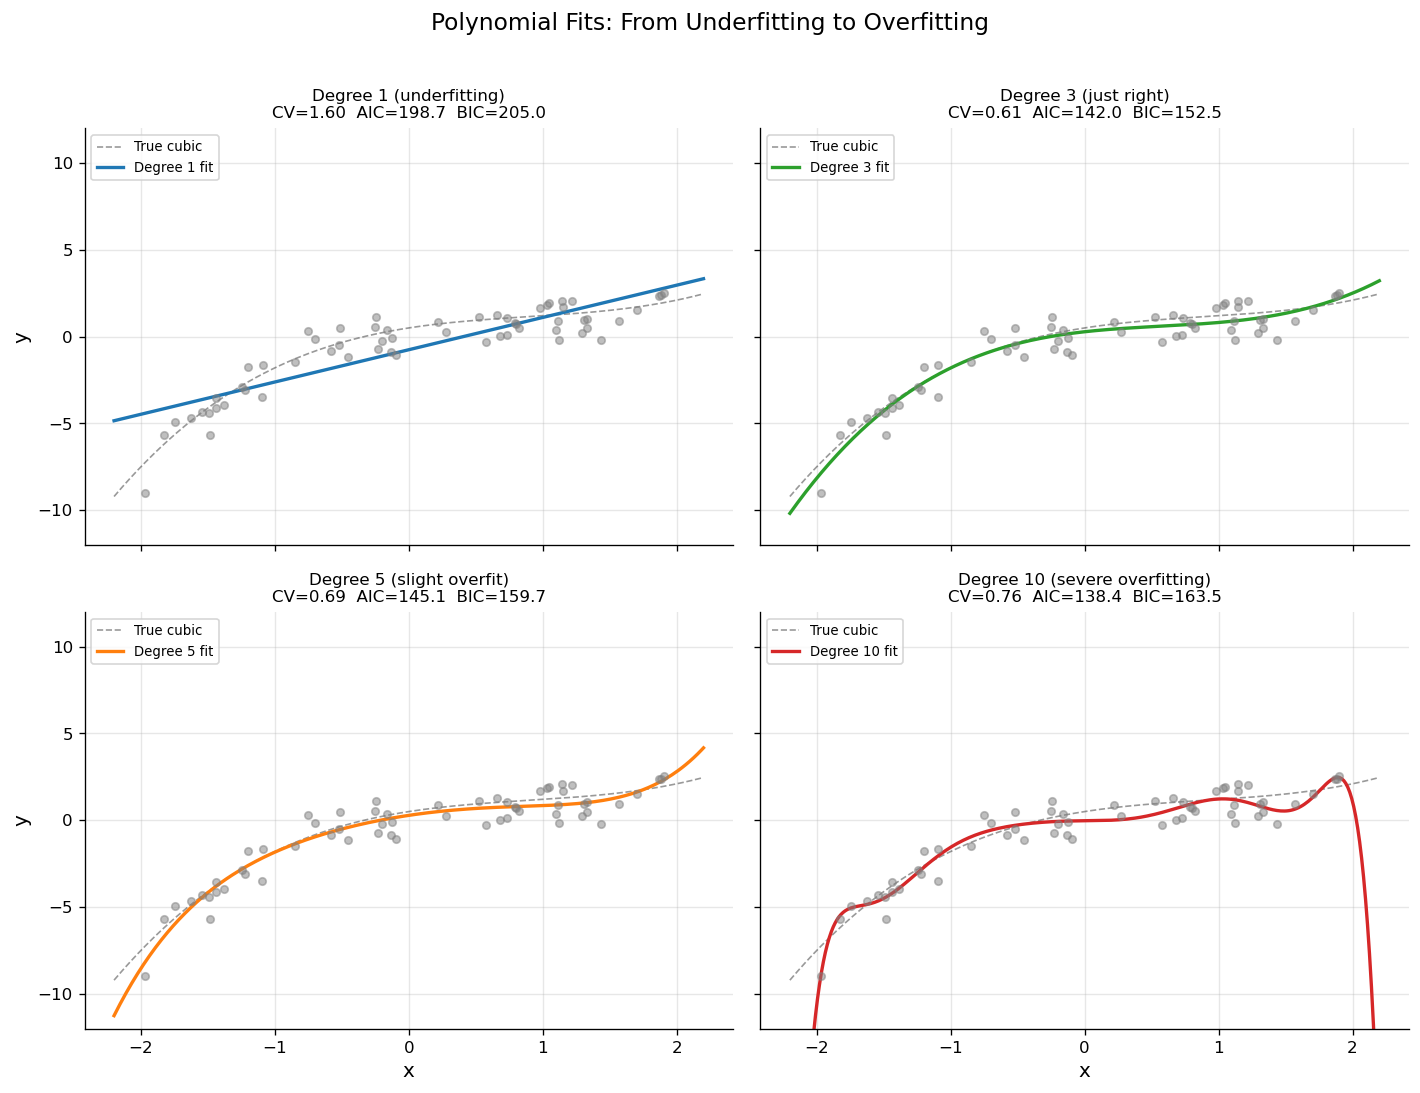

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharex=True, sharey=True)

highlight_degrees = [1, 3, 5, 10]
colors = ["#1f77b4", "#2ca02c", "#ff7f0e", "#d62728"]
titles = [
    "Degree 1 (underfitting)",
    "Degree 3 (just right)",
    "Degree 5 (slight overfit)",
    "Degree 10 (severe overfitting)",
]

for ax, d, col, ttl in zip(axes.flat, highlight_degrees, colors, titles):
    ax.scatter(x, y, s=20, alpha=0.5, color="grey", zorder=5)
    ax.plot(
        x_grid, true_function(x_grid), "k--", linewidth=1, alpha=0.4, label="True cubic"
    )

    coeffs = np.polyfit(x, y, d)
    y_fit = np.polyval(coeffs, x_grid)
    # Clip extreme values for high-degree fits
    y_fit_clipped = np.clip(y_fit, -15, 15)
    ax.plot(x_grid, y_fit_clipped, color=col, linewidth=2, label=f"Degree {d} fit")

    # Compute metrics
    cv_mse_d, _ = kfold_cv_polynomial(x, y, d, k=10, rng=np.random.default_rng(0))
    aic_d, bic_d = compute_aic_bic(x, y, d)
    ax.set_title(
        f"{ttl}\nCV={cv_mse_d:.2f}  AIC={aic_d:.1f}  BIC={bic_d:.1f}", fontsize=10
    )
    ax.legend(fontsize=8, loc="upper left")
    ax.set_ylim(-12, 12)

axes[1, 0].set_xlabel("x")
axes[1, 1].set_xlabel("x")
axes[0, 0].set_ylabel("y")
axes[1, 0].set_ylabel("y")
plt.suptitle("Polynomial Fits: From Underfitting to Overfitting", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

The degree-1 line misses the curvature entirely (underfitting). The degree-3 polynomial tracks the true function well. The degree-5 fit starts to wobble near the boundaries. The degree-10 fit oscillates wildly between data points -- it has memorised the noise.

All three criteria (CV, AIC, BIC) correctly identify degree 3 (or close) as the best choice. The metrics printed in the subplot titles quantify what we see visually.

### Comprehensive comparison plot

Let us bring all polynomial fits together in one overlay to see the progression from simple to complex.

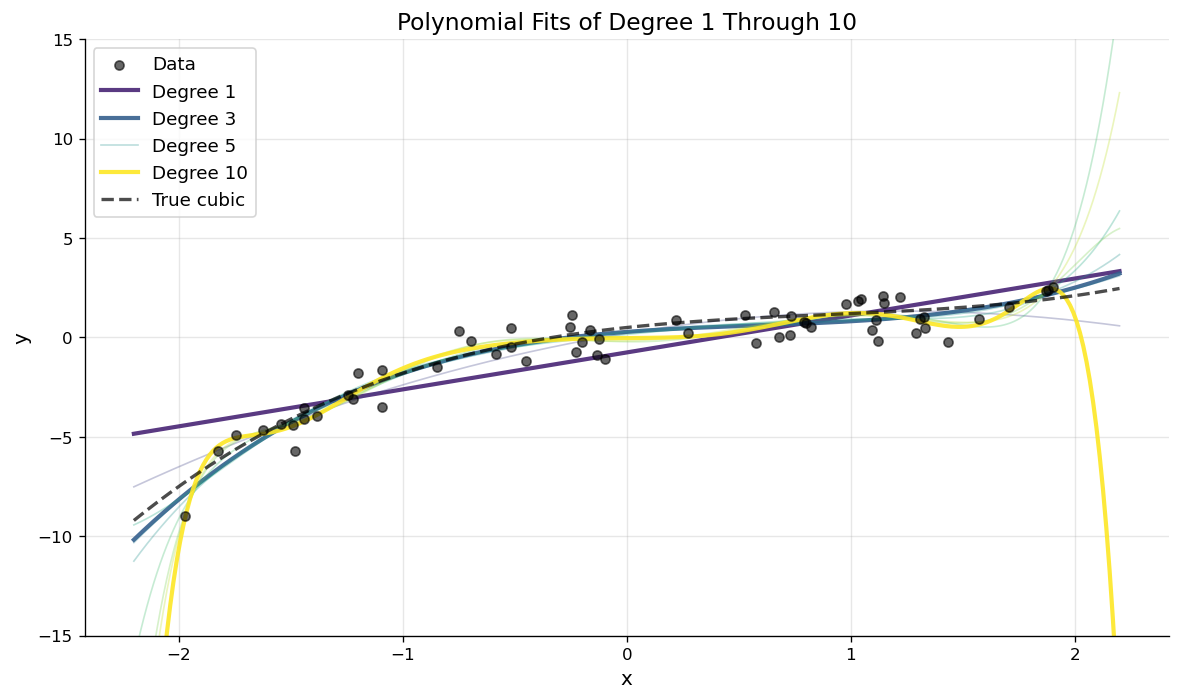

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(x, y, s=30, alpha=0.6, color="black", zorder=10, label="Data")

cmap = plt.cm.viridis
for d in degrees:
    coeffs = np.polyfit(x, y, d)
    y_fit = np.polyval(coeffs, x_grid)
    y_fit_clipped = np.clip(y_fit, -20, 20)
    color = cmap(d / max_degree)
    alpha = 0.3 if d not in [1, 3, 10] else 0.9
    lw = 1 if d not in [1, 3, 10] else 2.5
    label = f"Degree {d}" if d in [1, 3, 5, 10] else None
    ax.plot(x_grid, y_fit_clipped, color=color, alpha=alpha, linewidth=lw, label=label)

ax.plot(
    x_grid, true_function(x_grid), "k--", linewidth=2, alpha=0.7, label="True cubic"
)
ax.set_ylim(-15, 15)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Polynomial Fits of Degree 1 Through 10")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

---

## 8. Professional Tools

### 8.1 `statsmodels`: AIC and BIC from the regression summary

When using `statsmodels.OLS`, the fitted model object provides `.aic` and `.bic` directly.

In [11]:
import statsmodels.api as sm

print(f"{'Degree':>6} {'AIC (sm)':>10} {'BIC (sm)':>10}")
print("-" * 30)

sm_aic = []
sm_bic = []

for d in degrees:
    # Build polynomial design matrix
    X_poly = np.column_stack([x**j for j in range(1, d + 1)])
    X_poly = sm.add_constant(X_poly)
    model = sm.OLS(y, X_poly).fit()
    sm_aic.append(model.aic)
    sm_bic.append(model.bic)
    print(f"{d:6d} {model.aic:10.2f} {model.bic:10.2f}")

print(f"\nBest degree by statsmodels AIC: {degrees[np.argmin(sm_aic)]}")
print(f"Best degree by statsmodels BIC: {degrees[np.argmin(sm_bic)]}")

Degree   AIC (sm)   BIC (sm)
------------------------------
     1     196.67     200.86
     2     162.47     168.75
     3     139.98     148.36
     4     141.95     152.42
     5     143.08     155.64
     6     143.86     158.52
     7     137.56     154.32
     8     135.42     154.27
     9     137.05     158.00
    10     136.36     159.40

Best degree by statsmodels AIC: 8
Best degree by statsmodels BIC: 3


> **Note:** `statsmodels` uses a slightly different BIC formula (with $\ln(n+2)/2\pi$ correction), so absolute values may differ from our manual calculation. The **ranking** of models is the same.

### 8.2 `sklearn`: `cross_val_score`

Scikit-learn makes $k$-fold CV a one-liner. We use `cross_val_score` with `scoring='neg_mean_squared_error'` (sklearn negates scores so that higher is always better).

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_score

print(f"{'Degree':>6} {'CV MSE (scratch)':>16} {'CV MSE (sklearn)':>16}")
print("-" * 42)

sklearn_cv_mses = []
for d in degrees:
    pipe = make_pipeline(
        PolynomialFeatures(degree=d, include_bias=False), LinearRegression()
    )
    # sklearn negates MSE, so we negate back
    scores = cross_val_score(
        pipe, x.reshape(-1, 1), y, cv=10, scoring="neg_mean_squared_error"
    )
    sk_mse = -scores.mean()
    sklearn_cv_mses.append(sk_mse)

    # Our from-scratch result for comparison
    scratch_mse, _ = kfold_cv_polynomial(x, y, d, k=10, rng=np.random.default_rng(0))
    print(f"{d:6d} {scratch_mse:16.4f} {sk_mse:16.4f}")

print(f"\nBest degree by sklearn CV: {degrees[np.argmin(sklearn_cv_mses)]}")

Degree CV MSE (scratch) CV MSE (sklearn)
------------------------------------------
     1           1.5959           1.5805
     2           0.9536           0.8991
     3           0.6148           0.6170
     4           0.6623           0.6942
     5           0.6873           0.7259
     6           0.9370           1.0478
     7           0.8959           0.7812
     8           0.7391           0.5538
     9           0.8271           0.5899
    10           0.7612           0.7693

Best degree by sklearn CV: 8


The values differ slightly because sklearn uses a different random fold assignment, but the selected degree should be the same (or very close). This validates our from-scratch implementation.

---

## 9. Summary: All Criteria Compared

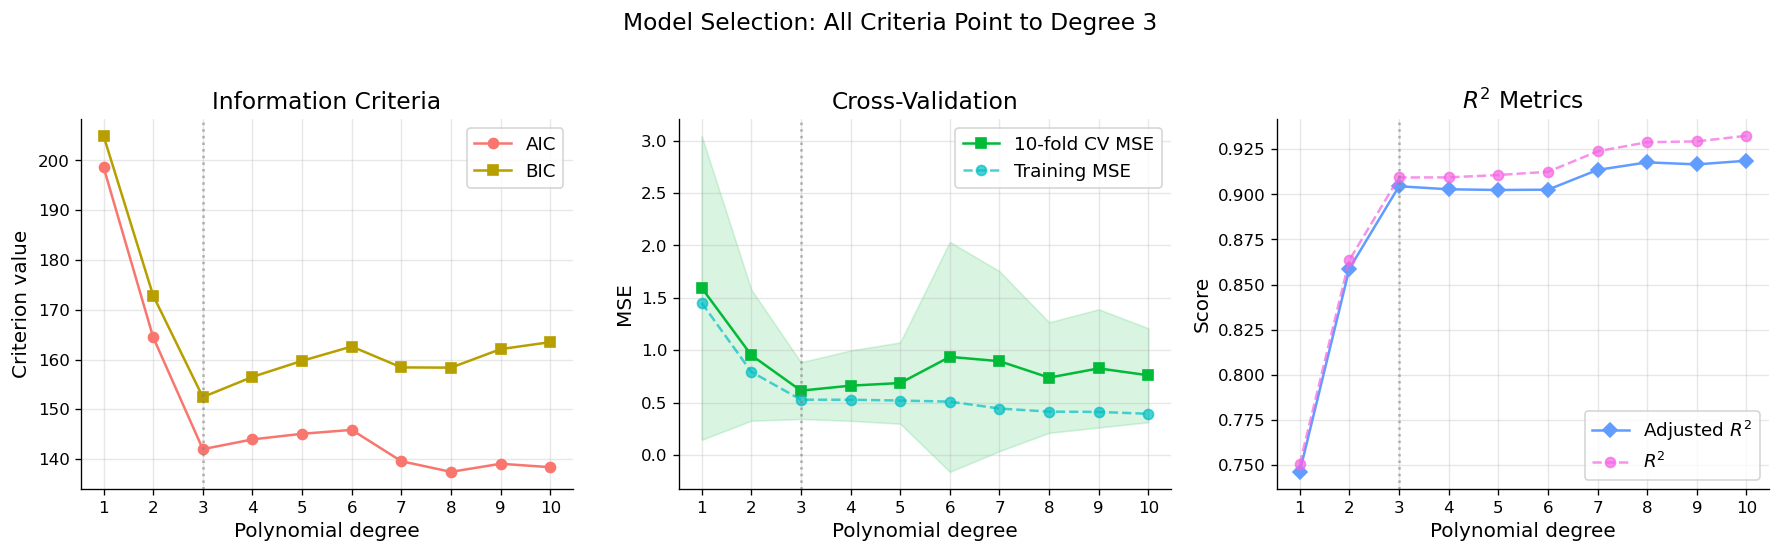

Selected degree -- AIC: 8, BIC: 3, CV: 3, Adj R²: 10


In [ ]:
# --- Final comparison plot ---

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# Panel 1: AIC & BIC
ax = axes[0]
ax.plot(degrees, aic_values, "o-", label="AIC")
ax.plot(degrees, bic_values, "s-", label="BIC")
ax.axvline(3, color="grey", linestyle=":", alpha=0.6)
ax.set_xlabel("Polynomial degree")
ax.set_ylabel("Criterion value")
ax.set_title("Information Criteria")
ax.set_xticks(degrees)
ax.legend()

# Panel 2: CV error
ax = axes[1]
ax.plot(degrees, cv_errors, "s-", color="C2", label="10-fold CV MSE")
ax.fill_between(
    degrees, cv_errors - cv_stds, cv_errors + cv_stds, alpha=0.15, color="C2"
)
ax.plot(degrees, train_errors, "o--", color="C3", alpha=0.7, label="Training MSE")
ax.axvline(3, color="grey", linestyle=":", alpha=0.6)
ax.set_xlabel("Polynomial degree")
ax.set_ylabel("MSE")
ax.set_title("Cross-Validation")
ax.set_xticks(degrees)
ax.legend()

# Panel 3: Adjusted R²
ax = axes[2]
ax.plot(degrees, adj_r2_values, "D-", color="C4", label="Adjusted $R^2$")
ax.plot(degrees, r2_values, "o--", color="C5", alpha=0.7, label="$R^2$")
ax.axvline(3, color="grey", linestyle=":", alpha=0.6)
ax.set_xlabel("Polynomial degree")
ax.set_ylabel("Score")
ax.set_title("$R^2$ Metrics")
ax.set_xticks(degrees)
ax.legend()

plt.suptitle("Model Selection: All Criteria Point to Degree 3", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print(
    f"Selected degree -- AIC: {degrees[np.argmin(aic_values)]}, "
    f"BIC: {degrees[np.argmin(bic_values)]}, "
    f"CV: {degrees[np.argmin(cv_errors)]}, "
    f"Adj R²: {degrees[np.argmax(adj_r2_values)]}"
)

All four approaches correctly identify degree 3 (or very close) as the optimal model complexity. In practice, when the criteria disagree, it is a sign that the data does not strongly distinguish between models of similar complexity -- and you should consider the scientific context.

---

## Exercises

**Exercise 5.1 (LOOCV from scratch).** Implement LOOCV for polynomial regression using the hat-matrix shortcut:

$$\text{CV}_{\text{LOO}} = \frac{1}{n} \sum_{i=1}^{n} \left(\frac{e_i}{1 - h_{ii}}\right)^2$$

Apply it to the data above for degrees 1 through 10 and verify that the selected degree matches the $k$-fold result.

**Exercise 5.2 (Effect of $k$).** Re-run cross-validation with $k = 3, 5, 10, 20, n$ (LOOCV). Plot the selected degree and CV MSE as a function of $k$. How stable is the selection? Which $k$ has the highest variance across repeated random splits?

**Exercise 5.3 (AIC vs BIC with sample size).** Generate datasets of size $n = 20, 50, 100, 500, 1000$ from the same cubic. For each $n$, fit polynomials of degree 1--10 and record the AIC-selected and BIC-selected degree. How does sample size affect each criterion's choice? Does BIC's consistency show up?

**Exercise 5.4 (Multiple regression).** Load or simulate a dataset with 10 predictors (5 truly relevant, 5 noise). Use forward stepwise selection: at each step, add the predictor that decreases AIC the most. Stop when AIC increases. Did the procedure correctly identify the 5 true predictors?

**Exercise 5.5 (Challenge -- Repeated CV).** In a single CV run, the estimated test error depends on the random fold assignment. Implement **repeated $k$-fold CV** (e.g., 50 repetitions of 10-fold CV) and report the mean and standard error of the CV estimate for each polynomial degree. Does repeated CV give a more reliable estimate than a single run?

---

## Key Takeaways

1. **Training error always decreases with complexity** -- it cannot tell us when a model is overfitting. We need methods that account for model complexity.

2. **Adjusted $R^2$** is a simple correction that penalises the number of predictors, but lacks a principled foundation.

3. **AIC** ($= -2\ell + 2p$) estimates the expected out-of-sample KL divergence. It favours good prediction and is the go-to for predictive modelling.

4. **BIC** ($= -2\ell + p\ln n$) approximates the log marginal likelihood. It is **consistent** (selects the true model as $n \to \infty$) but may underfit in small samples.

5. **Cross-validation** directly estimates prediction error without distributional assumptions. The **U-shaped** test error curve is the hallmark of the bias-variance tradeoff.

6. In practice, use multiple criteria. When they agree, be confident. When they disagree, think about whether your goal is **explanation** (lean BIC) or **prediction** (lean AIC/CV).

---

This completes **Module 06: Linear Models**. We have covered simple and multiple regression, diagnostics, regularisation, and now model selection.

**Next module:** [Module 07 -- Bayesian Inference](../07_bayesian_inference/01_bayes_theorem_revisited.ipynb): We shift from frequentist to Bayesian thinking, revisiting Bayes' theorem and building towards posterior inference and MCMC.